# 01 — Data Analysis, Preprocessing & Feature Engineering

Prepares the NASA C-MAPSS **FD001** data for the downstream modeling notebooks:

```
raw data → audit → EDA → RUL target → engine-level split → feature selection → scaling → prepared datasets
```

**Outputs (data contract)** — written to `data/processed/` and consumed by `02_regression.ipynb` and `03_classification.ipynb`:
`X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`, `train_engine_ids`.


## 1. Dataset Loading

- **Source:** NASA C-MAPSS FD001 — simulated run-to-failure turbofan trajectories (Saxena et al., PHM 2008; `data/raw/Damage Propagation Modeling.pdf`).
- **One row = one engine cycle.** Training trajectories run to failure; test trajectories stop before failure.
- **26 columns:** `engine_id`, `cycle`, 3 operating settings (`os_1`–`os_3`), 21 sensor channels (`sensor_1`–`sensor_21`). The raw files are whitespace-separated with no header.
- `RUL_FD001.txt` holds one ground-truth RUL value per test engine, measured at that engine's last recorded cycle.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42


C:\Users\hosse\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


In [2]:
train_data = pd.read_csv("data/raw/train_FD001.txt", sep=r"\s+", header=None)
test_data = pd.read_csv("data/raw/test_FD001.txt", sep=r"\s+", header=None)
RUL_data = pd.read_csv("data/raw/RUL_FD001.txt", sep=r"\s+", header=None)

# Assign the standard C-MAPSS schema names
column_names = (
    ["engine_id", "cycle"]
    + [f"os_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)
train_data.columns = column_names
test_data.columns = column_names


## 2. Initial Data Inspection


In [3]:
print("train_data:", train_data.shape)
print("test_data: ", test_data.shape)
print("RUL_data:  ", RUL_data.shape)


train_data: (20631, 26)
test_data:  (13096, 26)
RUL_data:   (100, 1)


In [4]:
train_data.head()


,engine_id,cycle,os_1,os_2,os_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


The test file has the identical 26-column schema (checked below via shape, missing values and duplicates), so its preview is omitted.


In [5]:
train_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   os_1       20631 non-null  float64
 3   os_2       20631 non-null  float64
 4   os_3       20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [6]:
for name, df in [("train", train_data), ("test", test_data)]:
    print(
        f"{name}: missing values = {df.isnull().sum().sum()}, "
        f"duplicated rows = {df.duplicated().sum()}"
    )


train: missing values = 0, duplicated rows = 0


test: missing values = 0, duplicated rows = 0


**Findings:** 20,631 training rows and 13,096 test rows across 100 engines each. No missing values and no duplicate rows in either file; a mix of `int64` and `float64` dtypes. The raw data is clean and ready for analysis.


## 3. Exploratory Data Analysis

### 3.1 Engine and Cycle Structure


In [7]:
print("engines in train_data:", train_data["engine_id"].nunique())
print("engines in test_data: ", test_data["engine_id"].nunique())


engines in train_data: 100
engines in test_data:  100


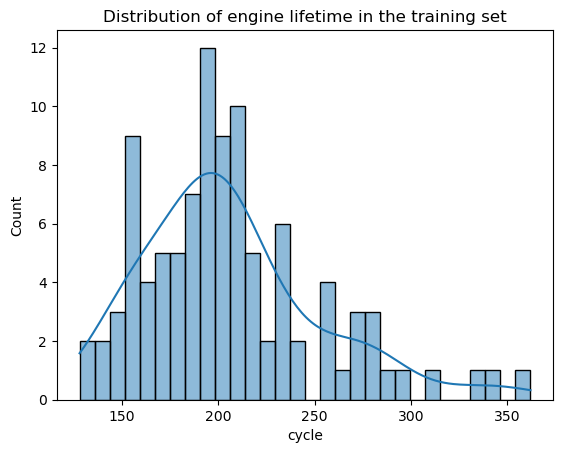

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

In [8]:
engine_life = train_data.groupby("engine_id")["cycle"].max()

sns.histplot(engine_life, bins=30, kde=True)
plt.title("Distribution of engine lifetime in the training set")
plt.show()

engine_life.describe()


Training lifetimes are roughly bell-shaped, spanning ~130 to ~360 cycles with a mean of ~206.


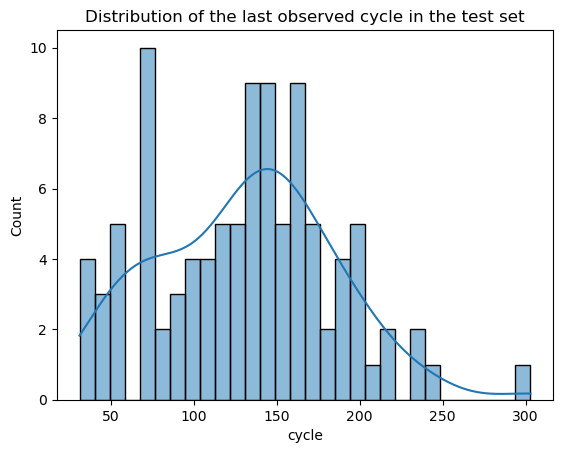

In [9]:
test_engine_life = test_data.groupby("engine_id")["cycle"].max()

sns.histplot(test_engine_life, bins=30, kde=True)
plt.title("Distribution of the last observed cycle in the test set")
plt.show()


Test engines stop earlier (~150–200 cycles typical) because test trajectories are truncated some time before failure — their RUL labels come from `RUL_FD001.txt` rather than from running to failure.


### 3.2 Operating Settings


In [10]:
os_data = train_data[["os_1", "os_2", "os_3"]]
os_data.describe().T


,count,mean,std,min,25%,50%,75%,max
os_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
os_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006
os_3,20631.0,100.000000,0.000000,100.0000,100.0000,100.0,100.0000,100.0000


- `os_3` is constant (100.0) in FD001 — a single fixed power setting — and carries no information, so it is excluded from the feature matrix later.
- `os_1` and `os_2` show only small nominal variation from simulated ambient noise; they are kept and standardized.


### 3.3 Sensor Behavior


In [11]:
sensor_df = train_data.iloc[:, 5:]  # sensor_1 ... sensor_21
sensor_df.describe().T


,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,4.660829e-13,1.3000,1.3000,1.3000,1.3000,1.3000


**Invariant sensors.** `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18` and `sensor_19` have zero standard deviation. In the FD001 setup (single cruise condition) these are inlet ambient conditions and closed-loop control targets (`T2`, `P2`, `epr`, `P15`, demanded corrected speeds), which stay thermodynamically constant. They carry no degradation signal and are pruned from the feature space later.

The remaining 15 sensors vary and capture progressive thermal/mechanical degradation (e.g. rising exhaust gas temperature, dropping HPC stall margin).


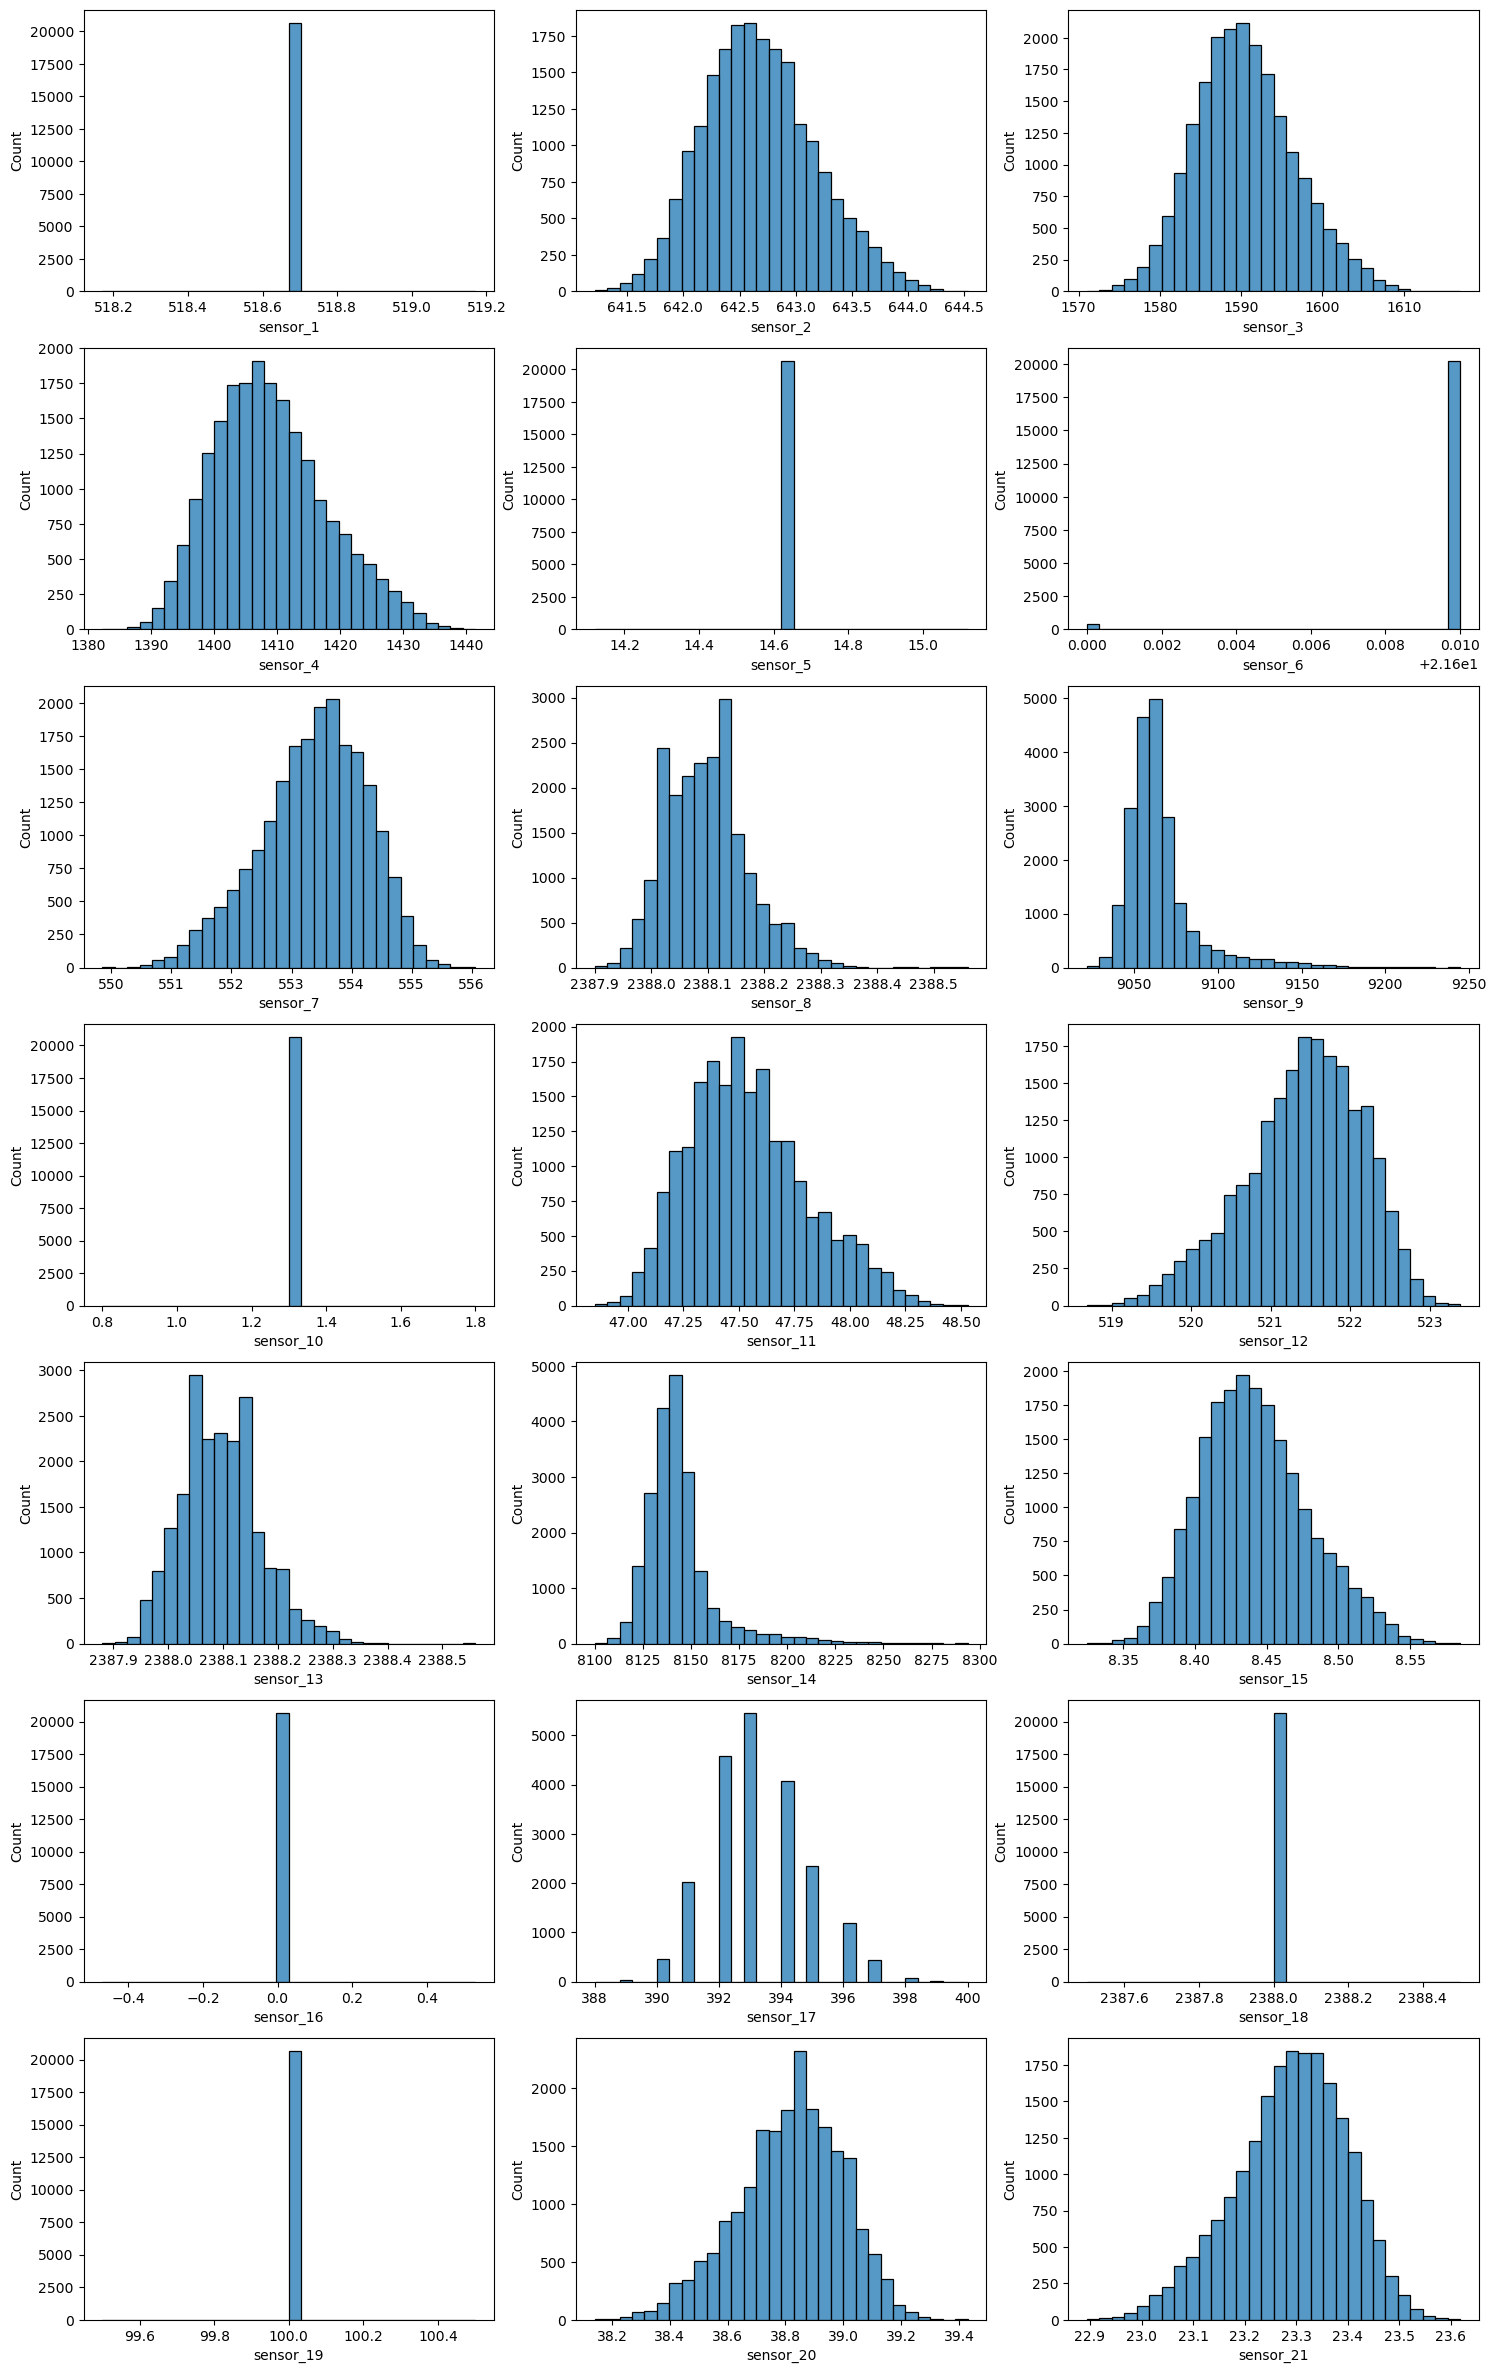

In [12]:
fig, axes = plt.subplots(7, 3, figsize=(18, 30))
for i, sensor in enumerate(sensor_df.columns):
    sns.histplot(sensor_df[sensor], bins=30, kde=False, ax=axes[i // 3, i % 3])
plt.show()


`sensor_6` stands out: it takes almost no distinct values (checked explicitly in Section 6.3) and is dropped as near-constant.


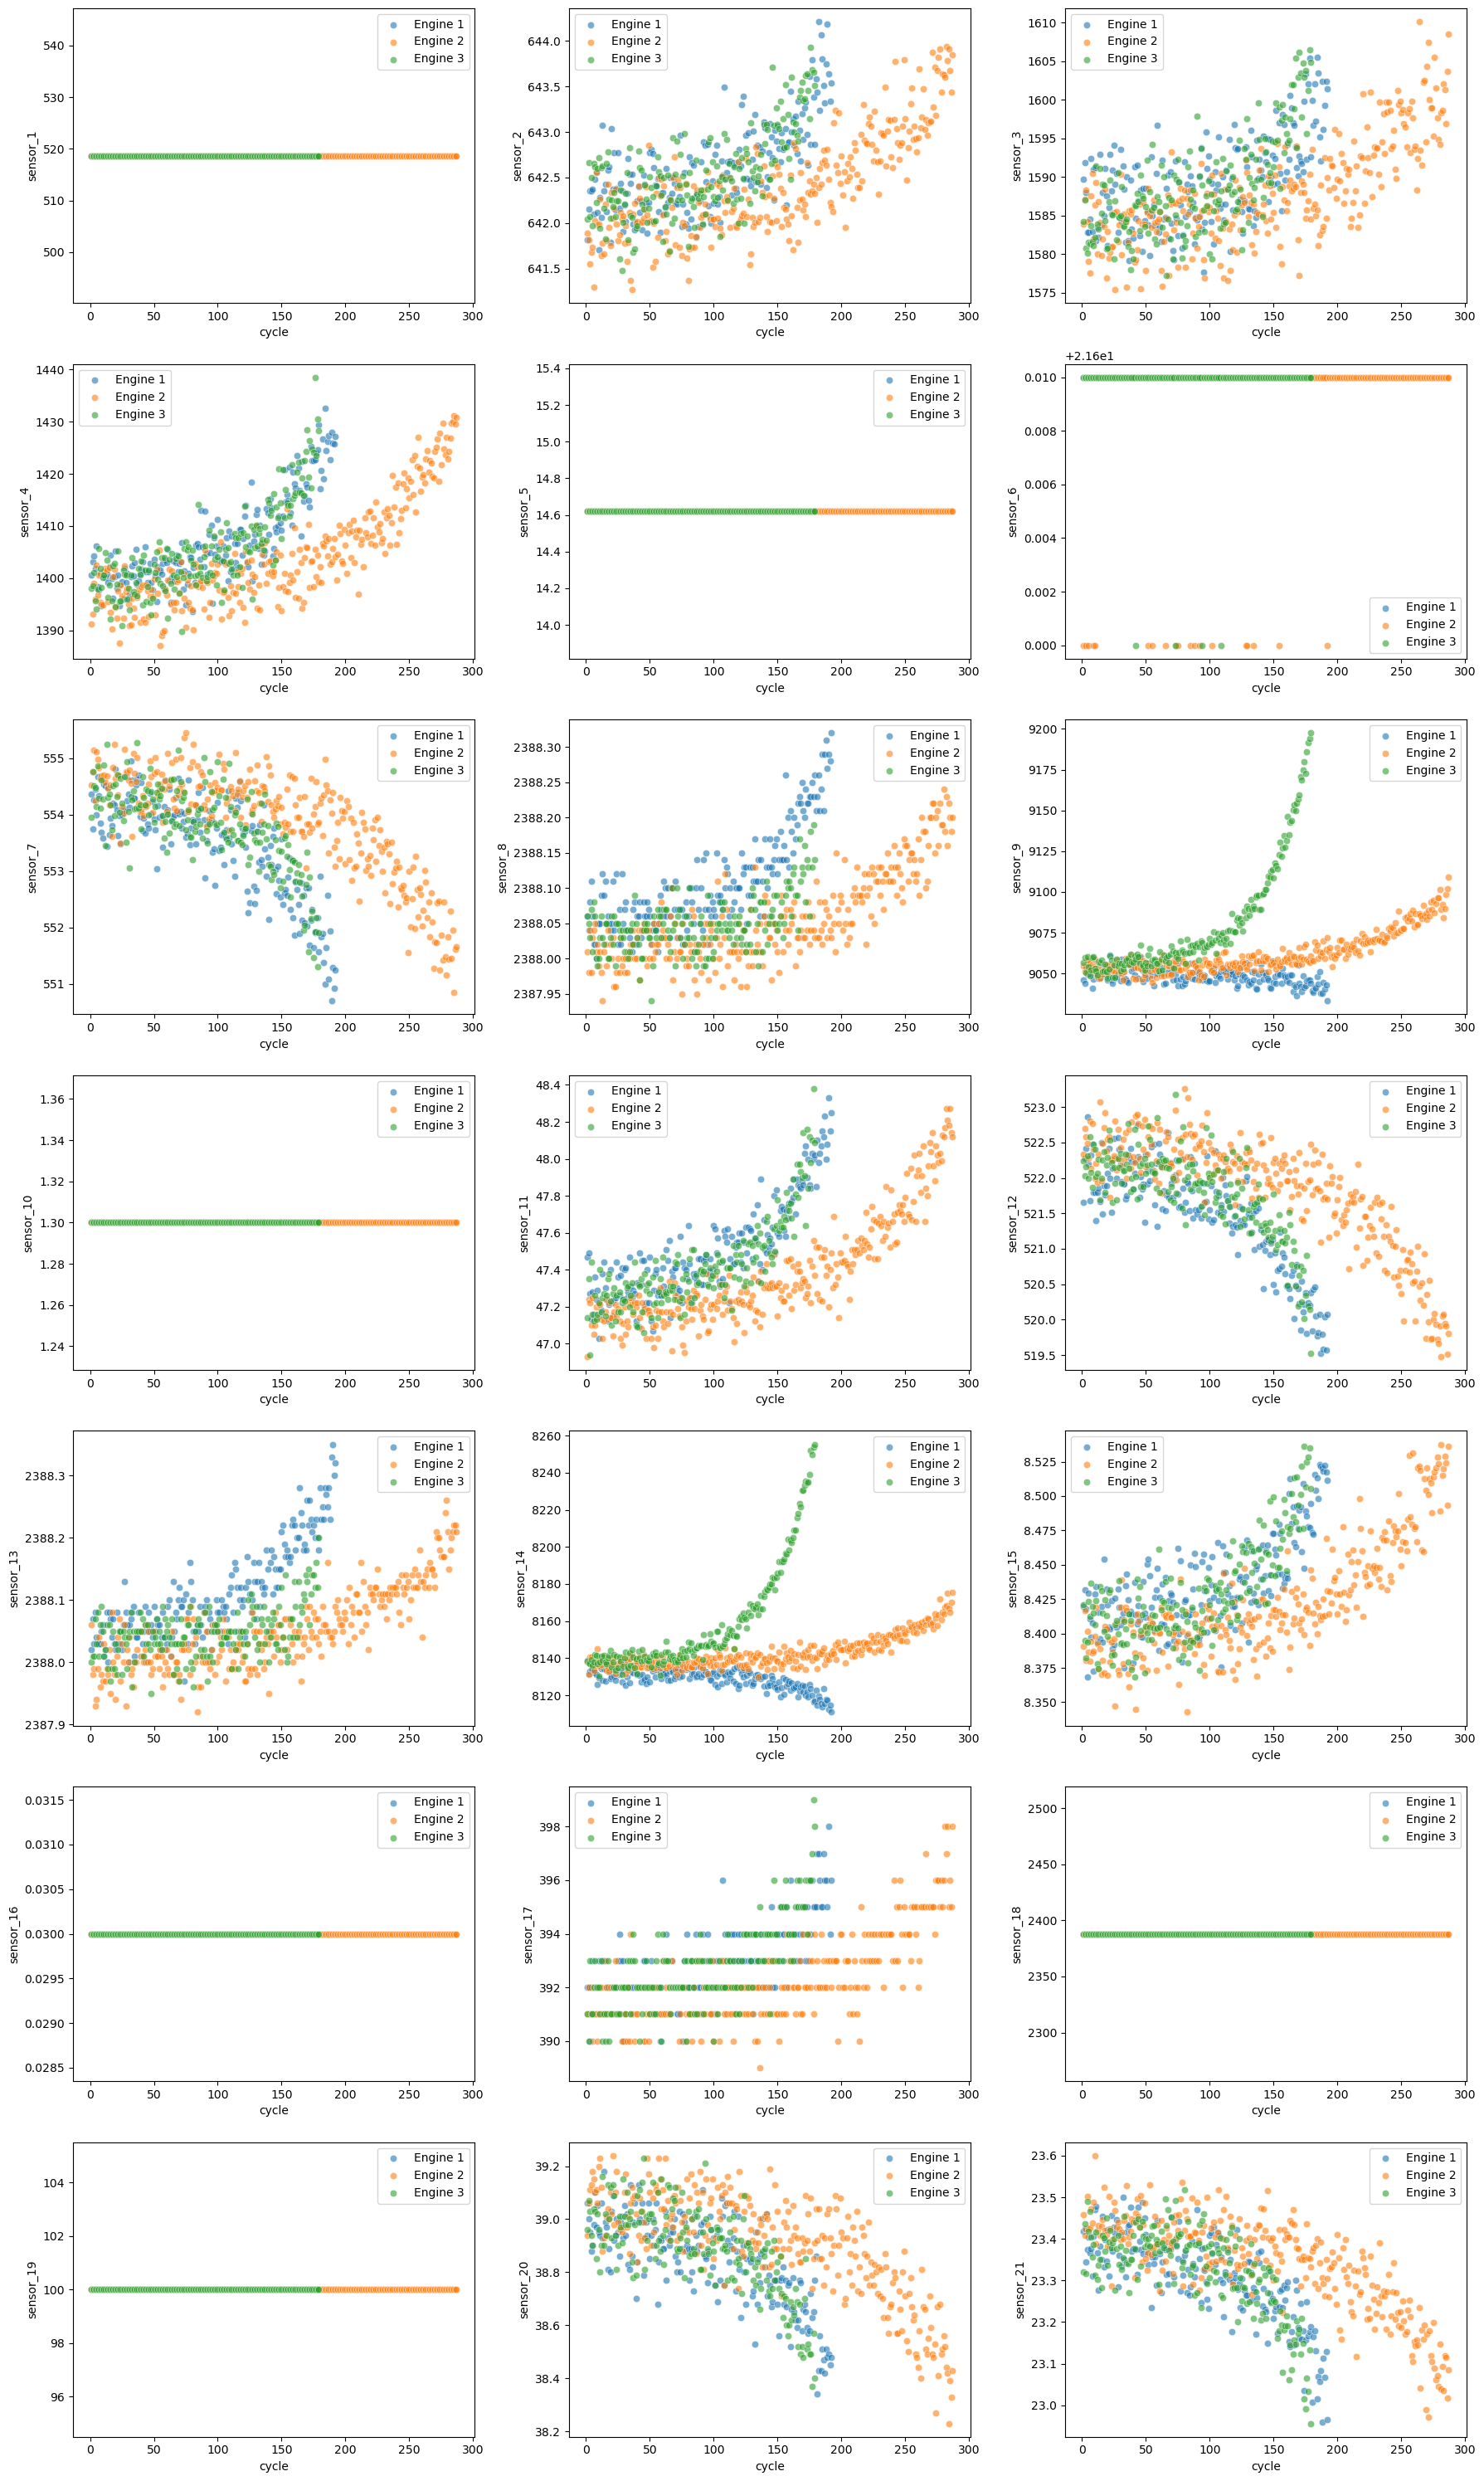

In [13]:
fig, axes = plt.subplots(7, 3, figsize=(18, 30))

for engine_id in range(1, 4):
    engine_df = train_data[train_data["engine_id"] == engine_id]
    for j, sensor in enumerate(sensor_df.columns):
        sns.scatterplot(
            data=engine_df, x="cycle", y=sensor,
            ax=axes[j // 3, j % 3], label=f"Engine {engine_id}", alpha=0.6,
        )

plt.tight_layout()
plt.show()


Tracked over cycles, the invariant sensors stay flat while most others trend clearly upward or downward — the degradation signal. Engines share the general trend but differ in starting point and slope, reflecting unit-to-unit variation.


### 3.4 Sensor Correlations


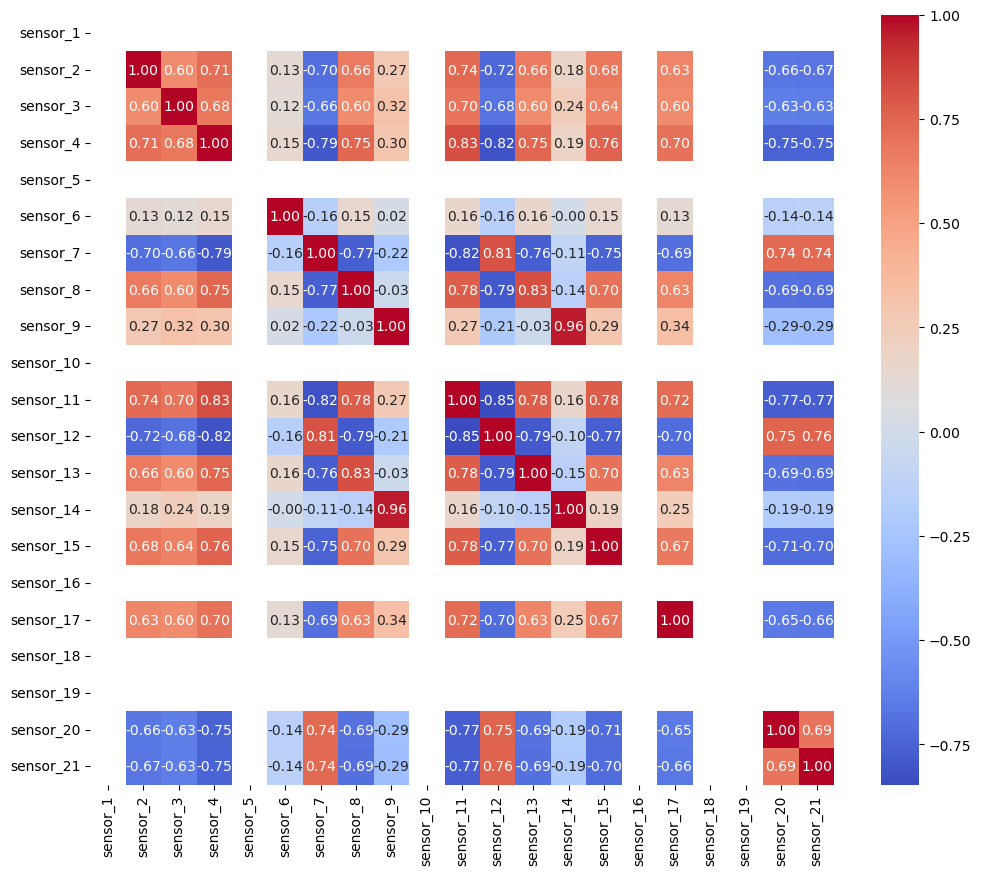

In [14]:
sensor_corr = sensor_df.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sensor_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.show()


`sensor_9` and `sensor_15` are highly correlated; the heatmap also confirms the six invariant sensors (zero variance, empty correlations). No additional columns are removed on this basis — the project keeps the full sensor set beyond the invariant and near-constant ones.


### 3.5 Ground-Truth Test RUL


In [15]:
RUL_data.columns = ["RUL"]
print("shape:", RUL_data.shape, "| missing:", RUL_data.isnull().sum().sum(), "| dtype:", RUL_data["RUL"].dtype)


shape: (100, 1) | missing: 0 | dtype: int64


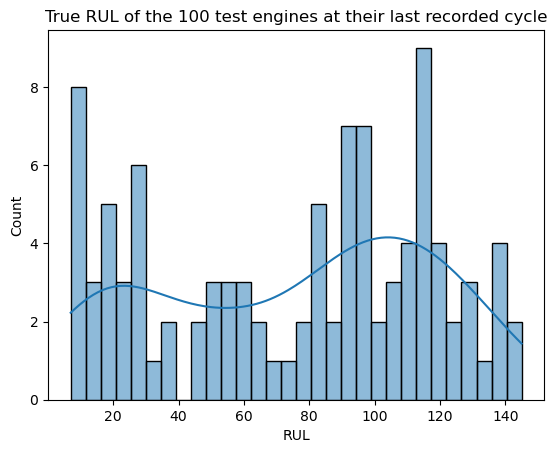

,count,mean,std,min,25%,50%,75%,max
RUL,100.0,75.52,41.76497,7.0,32.75,86.0,112.25,145.0


In [16]:
sns.histplot(RUL_data["RUL"], bins=30, kde=True)
plt.title("True RUL of the 100 test engines at their last recorded cycle")
plt.show()

RUL_data.describe().T


100 ground-truth values, one per test engine, ranging from 7 to 145 cycles remaining. These become `y_test` in Section 7.


## 4. RUL Target Construction

**Remaining Useful Life (RUL)** = number of cycles between the current observation and failure. Because every training trajectory runs to failure, the label for each row is computed directly from its own engine:

$$\text{RUL} = \text{max cycle of engine} - \text{current cycle}$$

The last recorded cycle of each engine gets RUL = 0. This is the prediction target for `02_regression.ipynb`.


In [17]:
max_cycles = train_data.groupby("engine_id")["cycle"].transform("max")
train_data["RUL"] = max_cycles - train_data["cycle"]


**Piecewise-linear labeling with cap 125.** A purely linear RUL target is unidentifiable early in life, where sensor degradation is buried in process and measurement noise (Saxena et al., Eq. 5; following the FD001 standard of Heimes, 2008). The target is therefore clipped at a fixed constant:

$$\text{RUL} = \min(\text{max cycle} - \text{cycle},\ 125)$$

The cap is a fixed constant, not tuned on any evaluation set. Training and validation labels are clipped; the official test evaluation remains on the 100 last-cycle points (whose true RUL is uncapped, see Section 3.5).


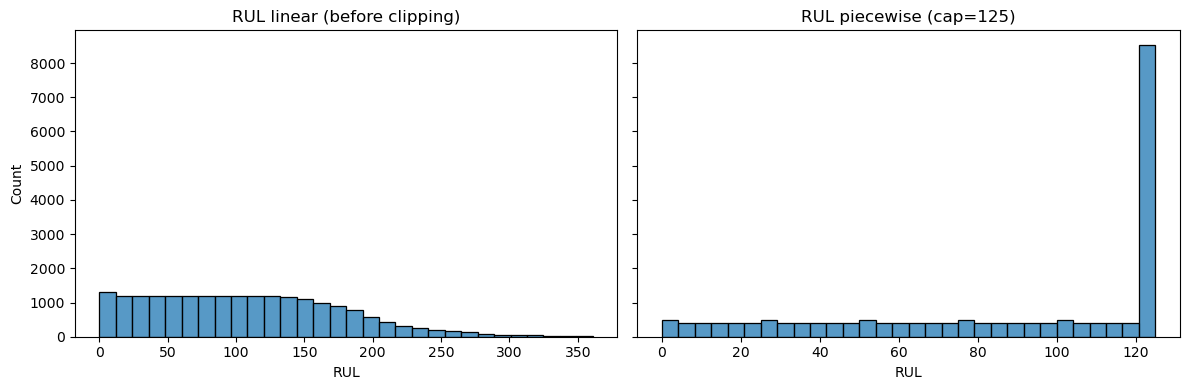

In [18]:
RUL_CAP = 125

train_data["RUL_original"] = train_data["RUL"]
train_data["RUL"] = train_data["RUL"].clip(upper=RUL_CAP)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.histplot(train_data["RUL_original"], bins=30, ax=ax[0])
ax[0].set_title("RUL linear (before clipping)")
ax[0].set_xlabel("RUL")

sns.histplot(train_data["RUL"], bins=30, ax=ax[1])
ax[1].set_title(f"RUL piecewise (cap={RUL_CAP})")
ax[1].set_xlabel("RUL")

plt.tight_layout()
plt.show()


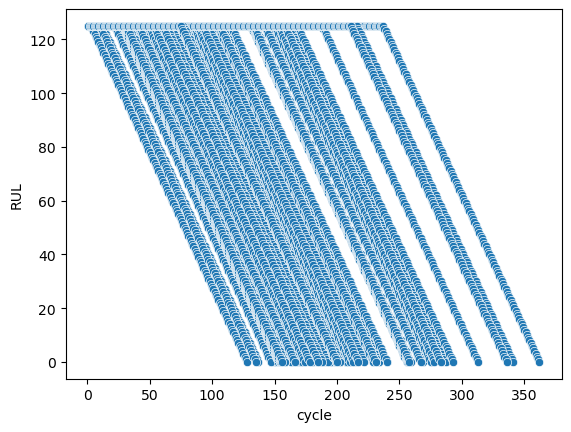

In [19]:
sns.scatterplot(x=train_data["cycle"], y=train_data["RUL"])
plt.show()


All engines follow the same pattern — RUL decreases one-for-one with cycle and flattens at the cap. Note that the cap (125) sits above the health-state boundaries used in `03_classification.ipynb` (100/30), so the clipping does not distort any class boundary.


## 5. Train / Validation / Test Split

**Strategy: engine-level split of the training file.** Cycles from the same engine are snapshots of one degradation trajectory and are strongly correlated — a random row-level split would place cycles of the same engine in both training and validation and leak information. The 100 training engines are therefore split into 80 training / 20 validation **engines** (`test_size=0.2`, `random_state=42`), and all rows of an engine stay together.

The 100 **test** engines are the official C-MAPSS test file — different engines entirely, kept aside for the final evaluations in Notebooks 02/03. The split is performed here, before any feature selection or scaling, so the scaler in Section 6.5 can be fitted on training engines only.


In [20]:
engine_id = train_data["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_id,
    test_size=0.2,
    random_state=SEED,
)

validation_df = train_data[train_data["engine_id"].isin(val_engines)]
train_df = train_data[train_data["engine_id"].isin(train_engines)]


In [21]:
print("validation engines:", validation_df["engine_id"].nunique())
print("train engines:     ", train_df["engine_id"].nunique())
assert len(train_df) + len(validation_df) == len(train_data)


validation engines: 20
train engines:      80


## 6. Feature Engineering & Preprocessing

### 6.1 Removing Non-Informative Columns

Dropped from the modeling frames:

- **Identifiers:** `cycle`, `engine_id` — the model must learn degradation from sensor physics, not count cycles or units.
- **Constant setting:** `os_3` (zero variance, Section 3.2).
- **Invariant sensors:** `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19` (zero variance, Section 3.3).
- **Helper column:** `RUL_original` (kept only to illustrate the cap in Section 4).

`test_data` keeps `engine_id` and `cycle` for now — they are needed to order the test rows and will be removed at final assembly (Section 7.4).

`train_engine_ids` (the engine ID of every training row) is captured **before** `engine_id` is dropped: it is the grouping key downstream notebooks use for engine-aware cross-validation.


In [22]:
train_engine_ids = train_df["engine_id"]


In [23]:
removed_list = [
    "cycle", "engine_id", "os_3",
    "sensor_1", "sensor_5", "sensor_10", "sensor_16", "sensor_18", "sensor_19",
    "RUL_original",
]

train_df = train_df.drop(removed_list, axis=1)
validation_df = validation_df.drop(removed_list, axis=1)

# test_data keeps engine_id/cycle for ordering; drop only the constant/uninformative columns
test_data = test_data.drop(
    ["os_3", "sensor_1", "sensor_5", "sensor_10", "sensor_16", "sensor_18", "sensor_19"],
    axis=1,
)


### 6.2 Outlier Check


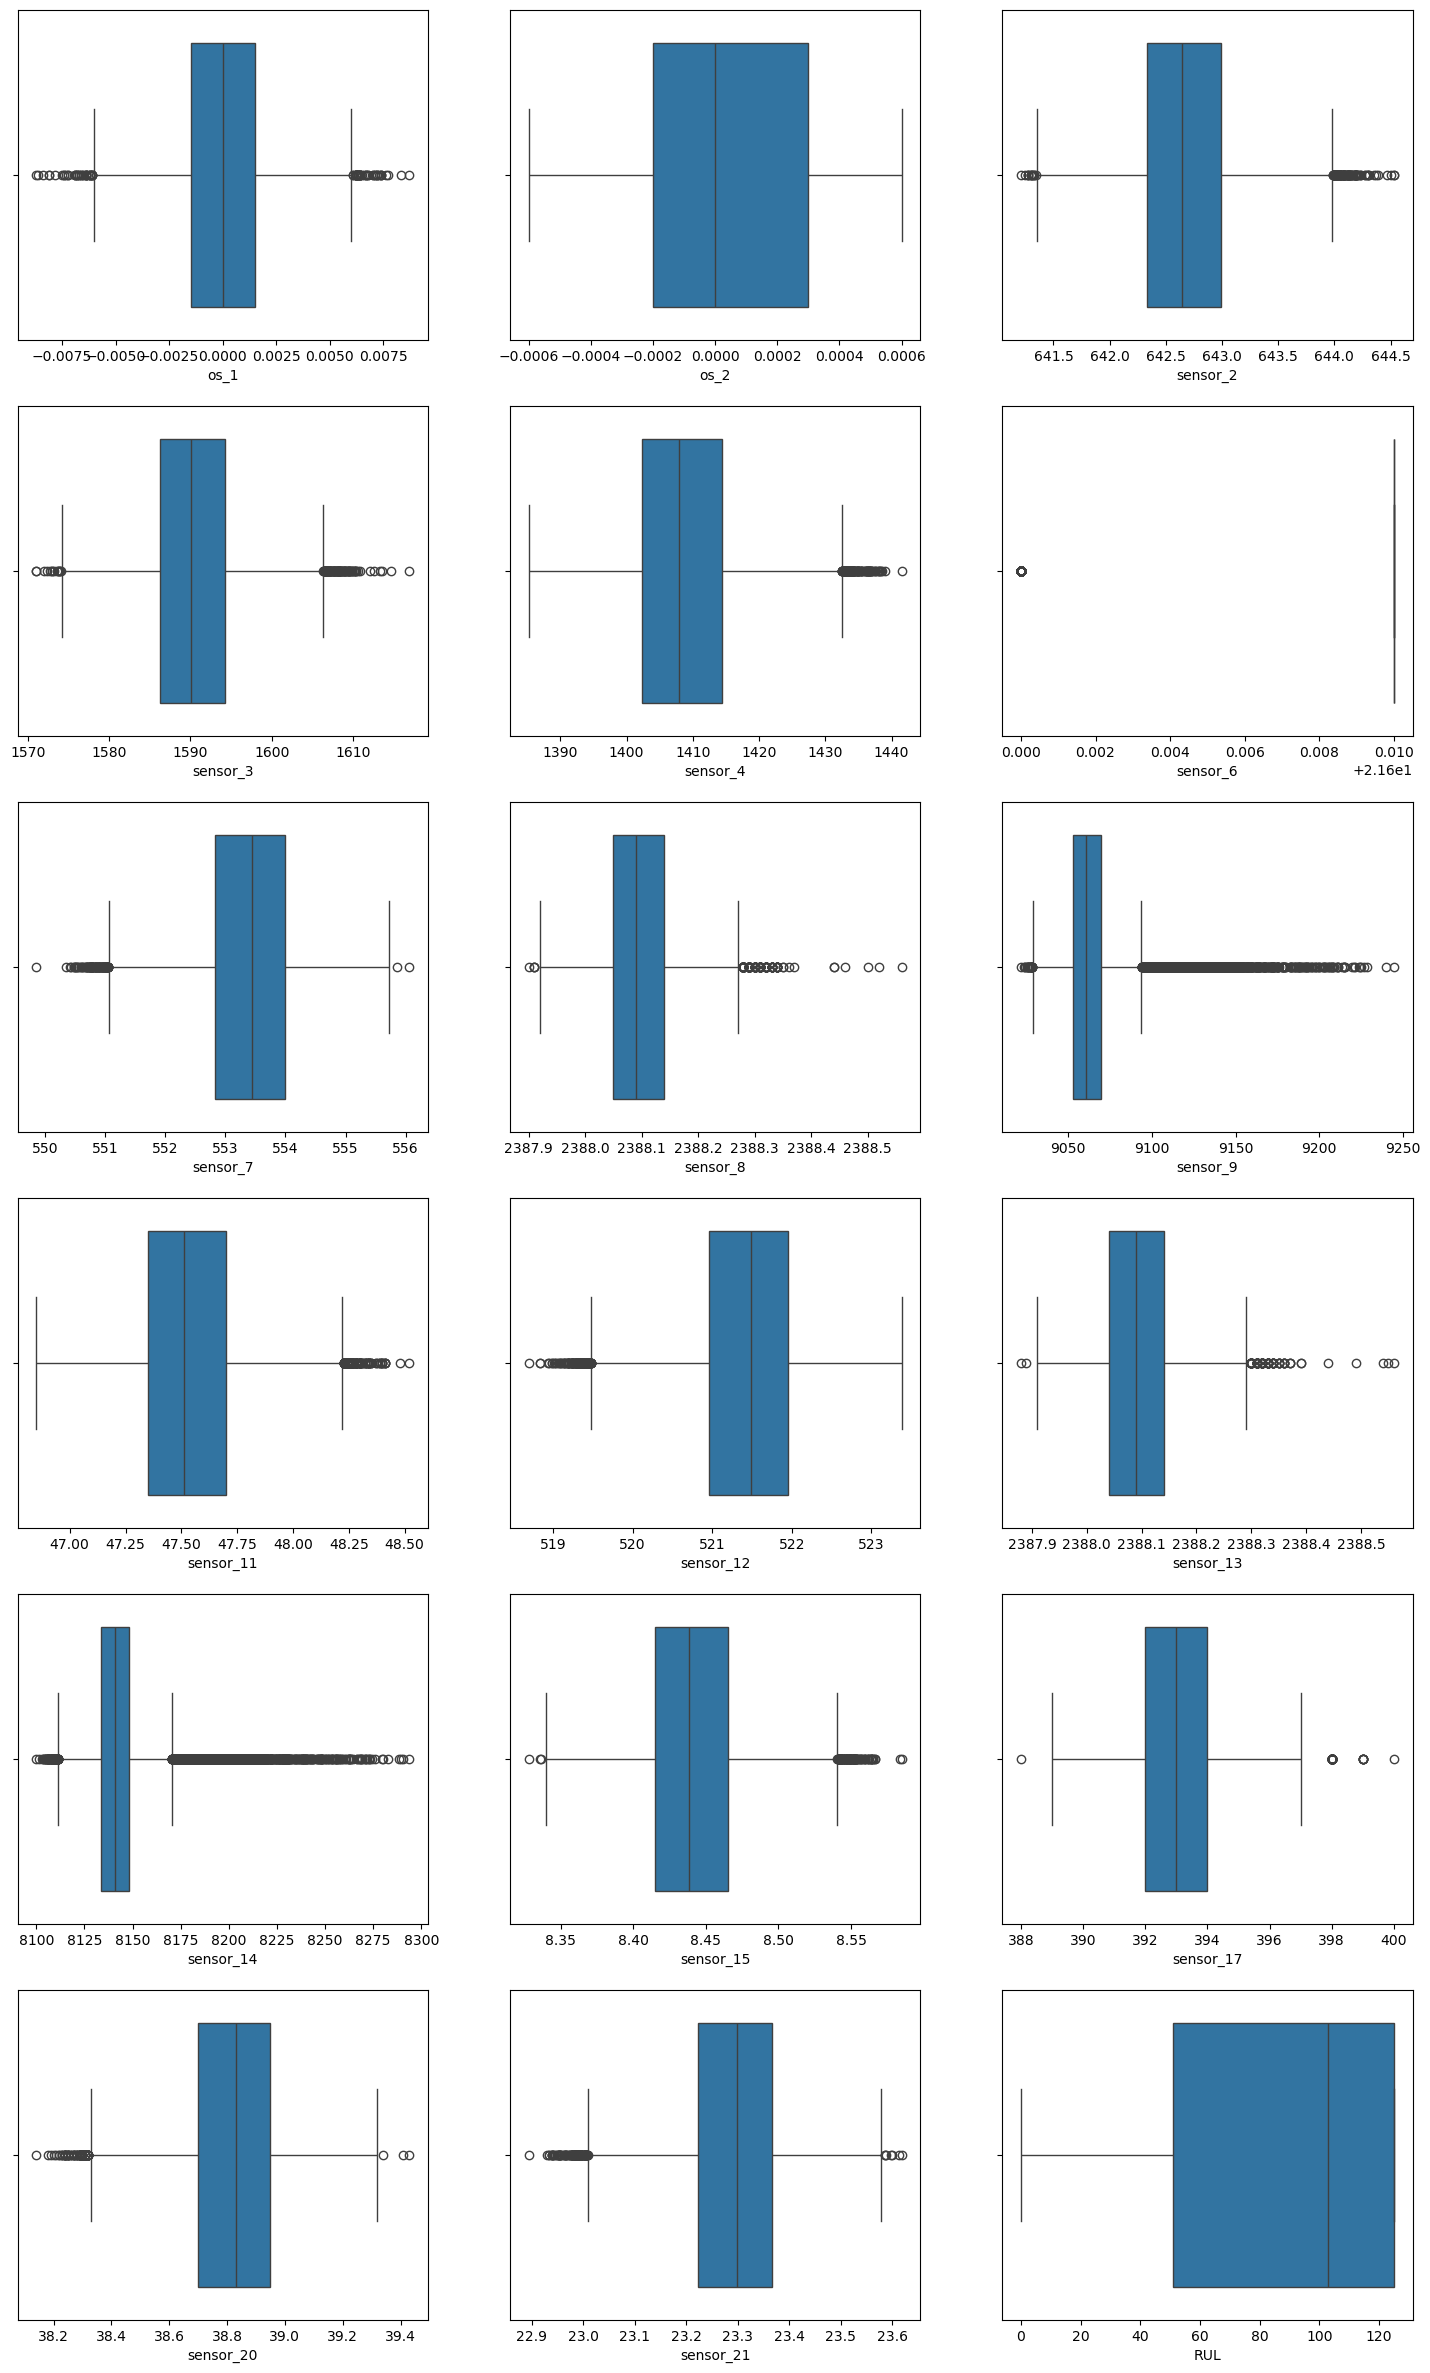

In [24]:
fig, axes = plt.subplots(6, 3, figsize=(18, 30))
for i, item in enumerate(train_df.columns):
    sns.boxplot(x=train_df[item], ax=axes[i // 3, i % 3])
plt.show()


**Outliers are kept.** Extreme readings here are not data errors — they reflect real operating variation and late-stage degradation toward end-of-life. Removing them would discard exactly the information RUL prediction depends on.


### 6.3 Near-Constant Sensor Removal


In [25]:
print("distinct values:", train_df["sensor_6"].nunique())
train_df["sensor_6"].value_counts()


distinct values: 2


sensor_6
21.61    16247
21.60      314
Name: count, dtype: int64

`sensor_6` takes only two values (21.61 in 98% of rows, 21.60 otherwise) — effectively constant and of no use to the model. It is dropped from all three datasets.


In [26]:
train_df = train_df.drop(["sensor_6"], axis=1)
validation_df = validation_df.drop(["sensor_6"], axis=1)
test_data = test_data.drop(["sensor_6"], axis=1)


### 6.4 Reducing the Test Set

The ground truth in `RUL_FD001.txt` refers to each test engine's state at its **final recorded cycle**. The test file is therefore reduced to one terminal observation per engine. `engine_id` and `cycle` are retained until final assembly to guarantee correct ordering and alignment.


In [27]:
test_data = (
    test_data
    .sort_values(["engine_id", "cycle"])
    .groupby("engine_id")
    .tail(1)
    .sort_values("engine_id")
    .reset_index(drop=True)
)
print("test_data after reduction:", test_data.shape)


test_data after reduction: (100, 18)


### 6.5 Standardization (Scaling)

The 16 retained features (2 operating settings + 14 sensors) are standardized with `StandardScaler`. The scaler is **fitted exclusively on the training engines** (`train_df`) and then applied unchanged to validation and test — fitting on validation or test would leak information into training.


In [28]:
scaler = StandardScaler()

scale_cols = [
    "os_1", "os_2", "sensor_2", "sensor_3", "sensor_4", "sensor_7",
    "sensor_8", "sensor_9", "sensor_11", "sensor_12", "sensor_13",
    "sensor_14", "sensor_15", "sensor_17", "sensor_20", "sensor_21",
]

train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
validation_df[scale_cols] = scaler.transform(validation_df[scale_cols])
test_data[scale_cols] = scaler.transform(test_data[scale_cols])


## 7. Final Dataset Summary

Assembling the modeling frames:


In [29]:
X_train = train_df.drop(columns=["RUL"])
y_train = train_df["RUL"]

X_val = validation_df.drop(columns=["RUL"])
y_val = validation_df["RUL"]


In [30]:
# One terminal row per test engine, aligned with RUL_FD001.txt (rows sorted by engine ID)
X_test = test_data.drop(columns=["engine_id", "cycle"])
y_test = RUL_data

assert len(X_test) == len(y_test)


In [31]:
print(f"X_train: {X_train.shape}   y_train: {y_train.shape}   engines: {train_engine_ids.nunique()}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}   engines: {len(val_engines)}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}   engines: {len(X_test)}")
print()
print(f"y_train range: {y_train.min()} - {y_train.max()}  (capped at {RUL_CAP})")
print(f"y_test  range: {y_test['RUL'].min()} - {y_test['RUL'].max()}  (true RUL, uncapped)")
print()
print("Features:", list(X_train.columns))


X_train: (16561, 16)   y_train: (16561,)   engines: 80
X_val:   (4070, 16)   y_val:   (4070,)   engines: 20
X_test:  (100, 16)   y_test:  (100, 1)   engines: 100

y_train range: 0 - 125  (capped at 125)
y_test  range: 7 - 145  (true RUL, uncapped)

Features: ['os_1', 'os_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## 8. Outputs / Data Contract

The artifacts below are saved to `data/processed/` and are the **only** interface to the modeling notebooks.

| Object | Shape | Content | Consumed by |
|---|---|---|---|
| `X_train` | (16561, 16) | Standardized features, 80 engines, all cycles | 02, 03 |
| `y_train` | (16561,) | Piecewise-linear RUL target, capped at 125 | 02, 03 |
| `X_val` | (4070, 16) | Standardized features, 20 held-out engines | 02, 03 |
| `y_val` | (4070,) | Capped RUL for the validation engines | 02, 03 |
| `X_test` | (100, 16) | Standardized features, last cycle of each test engine | 02, 03 |
| `y_test` | (100, 1) | True RUL of each test engine (7–145) | 02, 03 |
| `train_engine_ids` | (16561,) | Engine ID of every training row — groups for engine-aware CV | 02, 03 |

`03_classification.ipynb` maps the RUL values to health states (Healthy / Warning / Critical); `02_regression.ipynb` uses them directly as the regression target.


In [32]:
df_list = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test,
    "train_engine_ids": train_engine_ids,
}

for name, df in df_list.items():
    df.to_csv(f"data/processed/{name}.csv", index=False)

print("Exported:", ", ".join(f"{name}.csv" for name in df_list))


Exported: X_train.csv, y_train.csv, X_val.csv, y_val.csv, X_test.csv, y_test.csv, train_engine_ids.csv
